In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sam_one = SAM()
sam_one.load_data('../../Subclustering/PVH/SAM_Allen_Institute_PVH.h5ad')

sam_two = SAM()
sam_two.load_data('../../Subclustering/PVH/SAM_MO_soupx_plus5_cleaned_PVH_07282026.h5ad')

sam_four = SAM()
sam_four.load_data('../../Subclustering/PVH/SAM_CJ_joined_v2_cleaned_03122025_PVH.h5ad')

sam_eight = SAM()
sam_eight.load_data('../../Subclustering/PVH/SAM_AC_ncbi_soupx_cleaned_PVH_03122025.h5ad')

sam_nine = SAM()
sam_nine.load_data('../../Subclustering/PVH/SAM_XT_joined_Slc17a6_cleaned_03122205_PVH.h5ad')

sam_ten = SAM()
sam_ten.load_data('../../Subclustering/PVH/SAM_DR_cleaned_PVH_07172026.h5ad')

In [3]:
sams = {'mg':sam_one,'mo':sam_two,'cj':sam_four,'ac':sam_eight,'xt':sam_nine,'dr':sam_ten}
#keys = {'mo':'ss_subclass_nounlabeled','cc':'subclass_id_label_crossed','ri':'subclass_id_label_crossed'}

sm = SAMAP(
    sams,
    f_maps = '../../BLASTMAPPING/maps/active_maps/hypo_proj/',
)

Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
20878 `mg` gene symbols match between the datasets and the BLAST graph.
18046 `mo` gene symbols match between the datasets and the BLAST graph.
15948 `cj` gene symbols match between the datasets and the BLAST graph.
20391 `ac` gene symbols match between the datasets and the BLAST graph.
18982 `xt` gene symbols match between the datasets and the BLAST graph.
22599 `dr` gene symbols match between the datasets and the BLAST graph.


In [4]:
sm.run(pairwise=True)

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 50.78137803077698
Correcting data with means. 53.73806977272034
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species xt...
Expanding neighbourhoods of species dr...
Indegree coarsening
0/1 (0, 9942)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 0 
Average alignment score (A.S.):  0.37486784382673477 
Max A.S. improvement: 0.8195081401340572 
Min A.S. improvement: 0.0
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 29.37410569190979
Correcting data with means. 30.232908725738525
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species xt...
Expanding neighbourhoods of species dr...
Indegree coarsening
0/1 (0, 9942)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 1 
Average alignment score (A.S.):  0.47827852118879427 
Max A.S. improvement: 0.5083040271086685 
Min A.S. improvement: -0.2525959865190263
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 44.02416372299194
Correcting data with means. 30.701902389526367
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species xt...
Expanding neighbourhoods of species dr...
Indegree coarsening
0/1 (0, 9942)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
ITERATION: 2 
Average alignment score (A.S.):  0.4906017896238787 
Max A.S. improvement: 0.17466166301657388 
Min A.S. improvement: -0.19638520560382872
Alignment score --- 0.4906017896238787
Running UMAP on the stitched manifolds.
Elapsed time

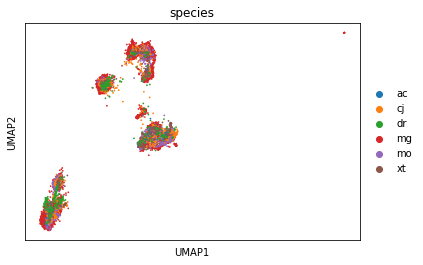

In [6]:
sc.pl.umap(sm.samap.adata, color = 'species')

In [7]:
save_samap(sm, '../../Subclustering/PVH/sm_hypoorgs_PVH_07282026.pkl')